# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
|Hilal Tsabitul Azmi Arba'i|5054251008|

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [41]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

In [3]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
data = pd.read_csv("bankruptcy.csv")
data.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [4]:
data.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

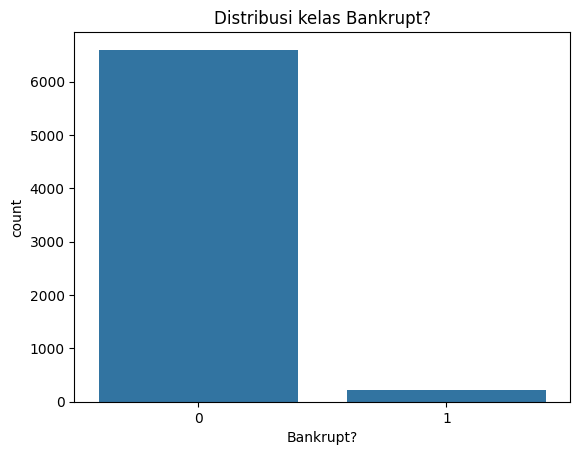

In [6]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

target= 'Bankrupt?'
plt.figure()
sns.countplot(x=target, data=data)
plt.title(f'Distribusi kelas {target}')

plt.show()

In [7]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [8]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

tidak ada missing value

feature selection

In [9]:
x = data.drop(columns=["Bankrupt?"])
y = data["Bankrupt?"]

x_train, x_test, y_train, y_test= train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
x_train.shape

(5455, 95)

In [11]:
y_train.shape

(5455,)

In [12]:
rfclass = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rfclass.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


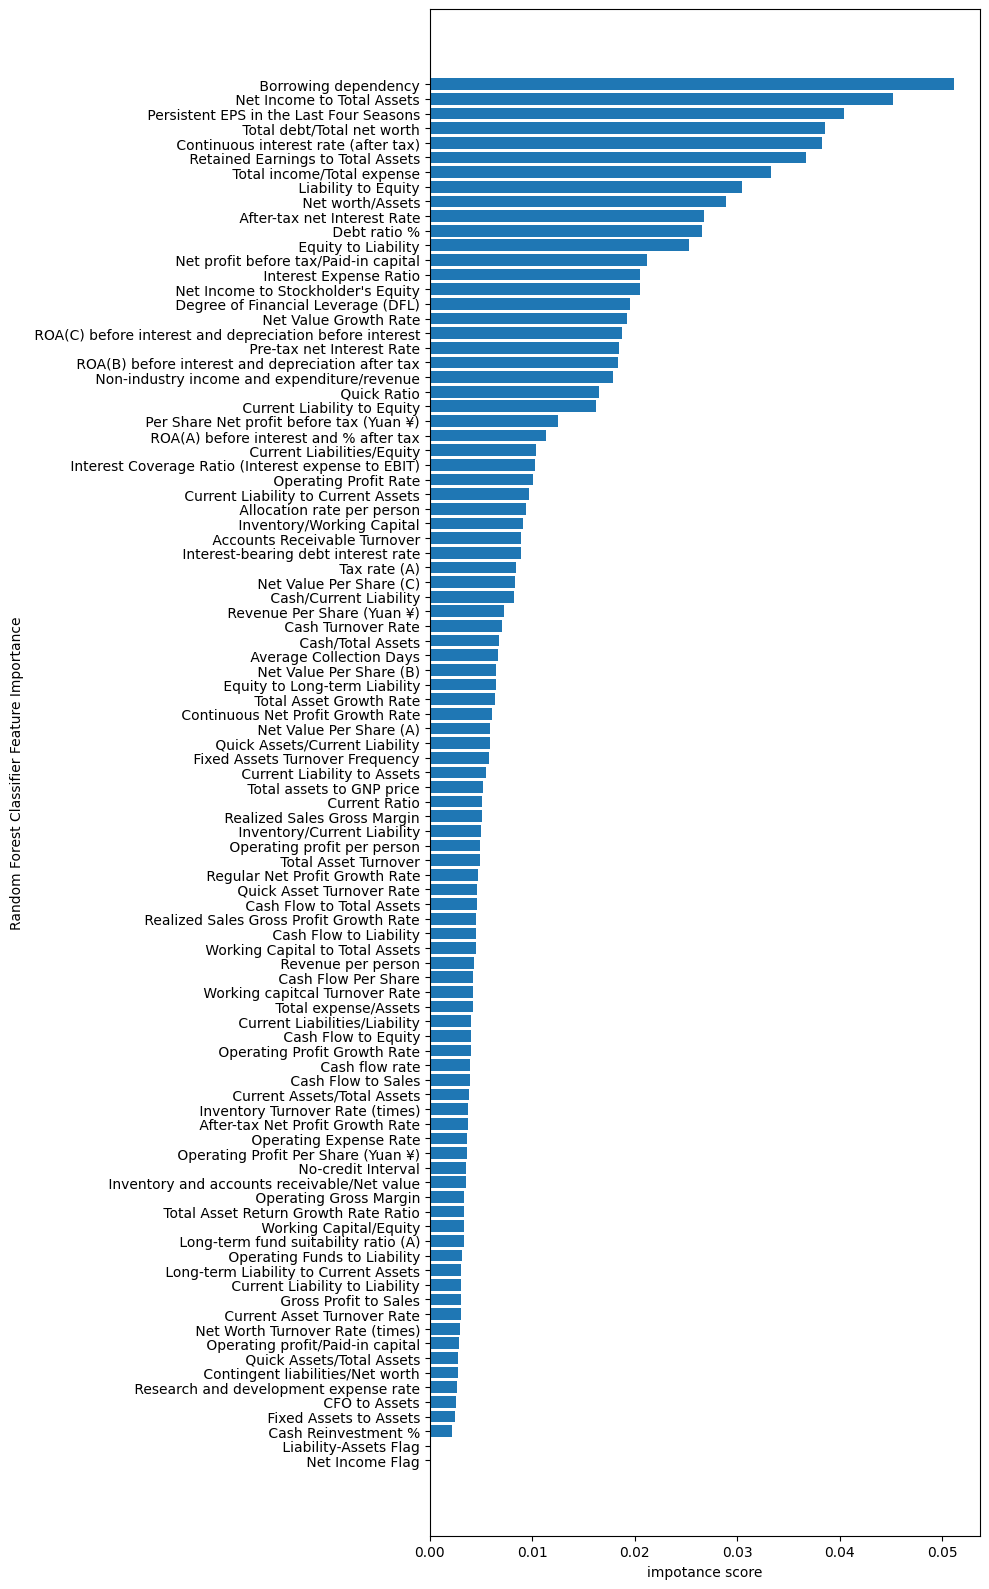

In [34]:
rf_fitur_penting = rfclass.feature_importances_
fitur_penting = pd.Series(rf_fitur_penting, index=x_train.columns)
sorted_yang_penting_plot = fitur_penting.sort_values(ascending=True)
sorted_nama_fitur = sorted_yang_penting_plot.index
sorted_value_fitur = sorted_yang_penting_plot.values

plt.figure(figsize=(10,16))
plt.barh(sorted_nama_fitur, sorted_value_fitur)
plt.xlabel("impotance score")
plt.ylabel("Random Forest Classifier Feature Importance")
plt.tight_layout()
plt.show()

In [14]:
ok_30_fitur_penting = fitur_penting.sort_values(ascending=False).head(30)
ok_30_fitur = ok_30_fitur_penting.index.tolist()
ok_30_fitur

[' Borrowing dependency',
 ' Net Income to Total Assets',
 ' Persistent EPS in the Last Four Seasons',
 ' Total debt/Total net worth',
 ' Continuous interest rate (after tax)',
 ' Retained Earnings to Total Assets',
 ' Total income/Total expense',
 ' Liability to Equity',
 ' Net worth/Assets',
 ' After-tax net Interest Rate',
 ' Debt ratio %',
 ' Equity to Liability',
 ' Net profit before tax/Paid-in capital',
 ' Interest Expense Ratio',
 " Net Income to Stockholder's Equity",
 ' Degree of Financial Leverage (DFL)',
 ' Net Value Growth Rate',
 ' ROA(C) before interest and depreciation before interest',
 ' Pre-tax net Interest Rate',
 ' ROA(B) before interest and depreciation after tax',
 ' Non-industry income and expenditure/revenue',
 ' Quick Ratio',
 ' Current Liability to Equity',
 ' Per Share Net profit before tax (Yuan ¥)',
 ' ROA(A) before interest and % after tax',
 ' Current Liabilities/Equity',
 ' Interest Coverage Ratio (Interest expense to EBIT)',
 ' Operating Profit Rate',


In [15]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.

data sudah numerik semua jadi tidak perlu melakukan encoding

sebenarnya ada hl lin yng lebih menarik dari data ini, yakni Net income flag memiliki nilai min 1 dan nilai maks 1 artinya data cuma memiliki 1 nilai unik. jadi kalau fitur ini di drop boleh boleh saja karena tidak akan berpengaruh ke split decision tree

In [16]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

In [23]:
x_train_ok = x_train[ok_30_fitur]
x_test_ok = x_test[ok_30_fitur]

print(x_train_ok.shape, x_test_ok.shape)

(5455, 30) (1364, 30)


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [24]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.
DT_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

DT_gini.fit(x_train_ok, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_gini = DT_gini.predict(x_test_ok)

print("Akurasi:", accuracy_score(y_test, y_pred_gini))
print()
print("Classification Report:")
report = classification_report(y_test, y_pred_gini, target_names=["Not Bankrupt", "Bankrupt"])
print(report)

Akurasi: 0.969208211143695

Classification Report:
              precision    recall  f1-score   support

Not Bankrupt       0.98      0.99      0.98      1320
    Bankrupt       0.55      0.27      0.36        44

    accuracy                           0.97      1364
   macro avg       0.76      0.63      0.67      1364
weighted avg       0.96      0.97      0.96      1364



## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [30]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.
DT_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

DT_entropy.fit(x_train_ok, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [31]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_entropy = DT_entropy.predict(x_test_ok)

print("Akurasi:", accuracy_score(y_test, y_pred_entropy))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_entropy, target_names=["Not Bankrupt", "Bankrupt"]))

Akurasi: 0.9714076246334311

Classification Report:
              precision    recall  f1-score   support

Not Bankrupt       0.98      0.99      0.99      1320
    Bankrupt       0.59      0.36      0.45        44

    accuracy                           0.97      1364
   macro avg       0.79      0.68      0.72      1364
weighted avg       0.97      0.97      0.97      1364



## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

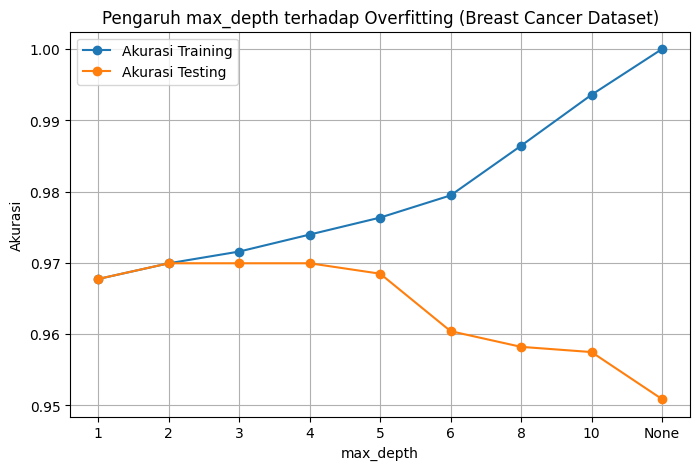

In [33]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).

"""
terlihat dari precision, recall, f1-score, dan support bahwa yang menggunakan 
entrophy memiliki skor terbaik
"""

depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(x_train_ok, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(x_train_ok)))
    test_scores.append(accuracy_score(y_test, model.predict(x_test_ok)))

depth_labels = [str(d) if d is not None else "None" for d in depths]

plt.figure(figsize=(8, 5))
plt.plot(depth_labels, train_scores, marker="o", label="Akurasi Training")
plt.plot(depth_labels, test_scores, marker="o", label="Akurasi Testing")
plt.xlabel("max_depth")
plt.ylabel("Akurasi")
plt.title("Pengaruh max_depth terhadap Overfitting (Breast Cancer Dataset)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

udah diatas

In [ ]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

ada pada grafik diatas

# 4. Evaluasi Model

In [46]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

y_pred_gini = DT_gini.predict(x_test_ok)
y_pred_entropy = DT_entropy.predict(x_test_ok)

def skor(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0),
    ]

pd.DataFrame(
    [skor(y_test, y_pred_gini), skor(y_test, y_pred_entropy)],
    index=["Gini", "Entropy"],
    columns=["Accuracy", "Precision", "Recall", "F1-Score"]
)

,Accuracy,Precision,Recall,F1-Score
Gini,0.969208,0.545455,0.272727,0.363636
Entropy,0.971408,0.592593,0.363636,0.450704


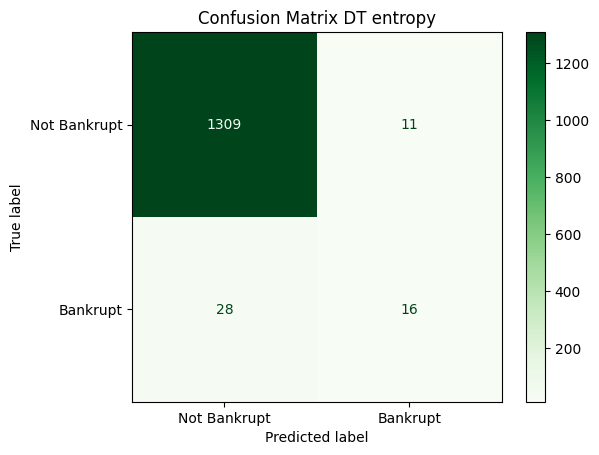

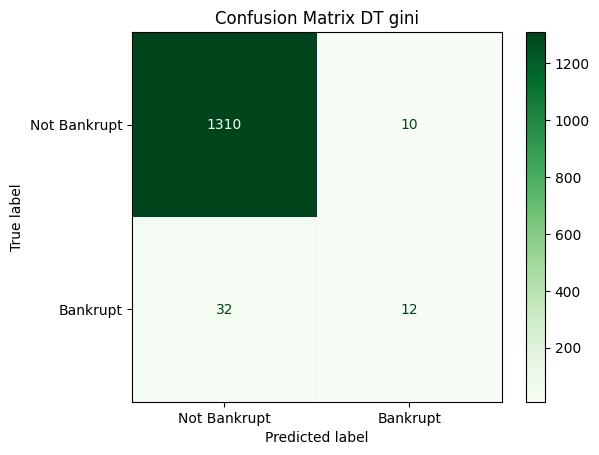

In [45]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.

cm2_entropy = confusion_matrix(y_test, y_pred_entropy)
disp2entropy = ConfusionMatrixDisplay(confusion_matrix=cm2_entropy, display_labels=["Not Bankrupt", "Bankrupt"])
disp2entropy.plot(cmap="Greens")
plt.title("Confusion Matrix DT entropy")
#plt.show()

cm2_gini = confusion_matrix(y_test, y_pred_gini)
disp2_gini = ConfusionMatrixDisplay(confusion_matrix=cm2_gini, display_labels=["Not Bankrupt", "Bankrupt"])
disp2_gini.plot(cmap="Greens")
plt.title("Confusion Matrix DT gini")
plt.show()

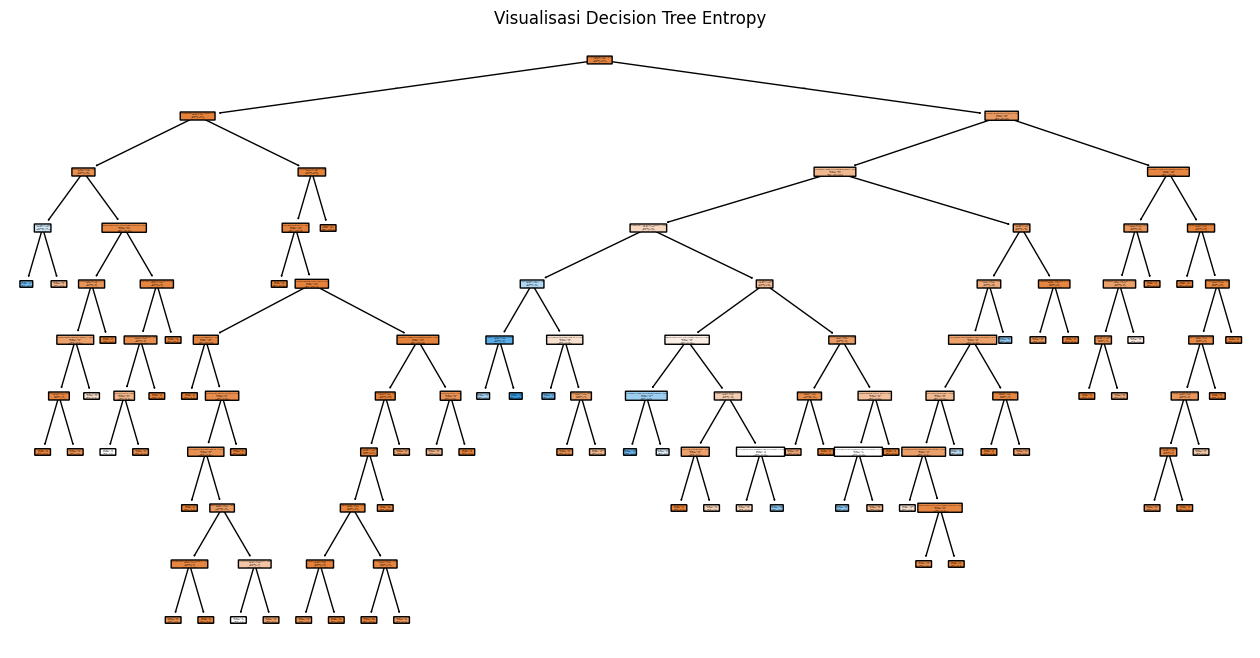

In [43]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.

plt.figure(figsize=(16, 8))
plot_tree(
    DT_entropy,
    filled=True,
    max_depth=10,
    rounded=True,
    feature_names=ok_30_fitur,
    class_names=["Not Bankrupt", "Bankrupt"]
)
plt.title("Visualisasi Decision Tree Entropy")
plt.show()

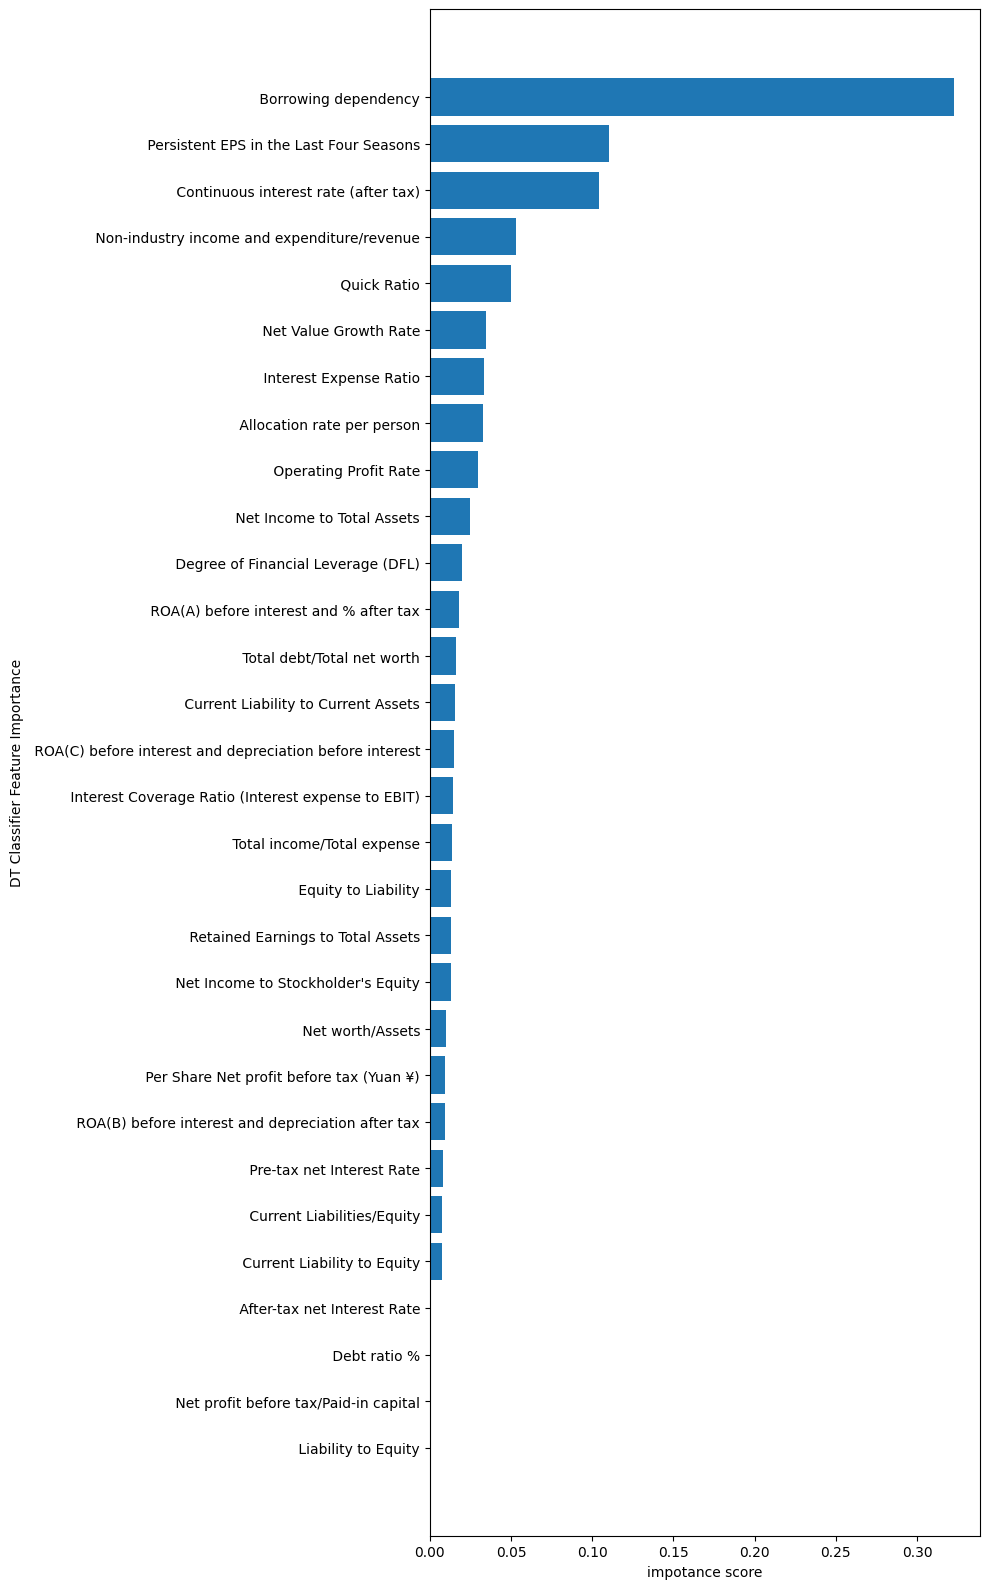

In [39]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.

DT_fitur_penting_entropy = DT_entropy.feature_importances_
fitur_penting_entropy = pd.Series(DT_fitur_penting_entropy, index=x_train_ok.columns)
sorted_yang_penting_plot_entropy = fitur_penting_entropy.sort_values(ascending=True)
sorted_nama_fitur_entropy = sorted_yang_penting_plot_entropy.index
sorted_value_fitur_entropy = sorted_yang_penting_plot_entropy.values

plt.figure(figsize=(10,16))
plt.barh(sorted_nama_fitur_entropy, sorted_value_fitur_entropy)
plt.xlabel("impotance score")
plt.ylabel("DT Classifier Feature Importance")
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

Hasil eksperimen menunjukkan bahwa Decision Tree dengan kriteria Entropy memberikan performa sedikit lebih baik, dengan akurasi 97,14%, precision 59,26%, recall 36,36%, dan F1-score 45,07% pada kelas Bankrupt, sedangkan Gini memperoleh akurasi 96,92%, precision 54,55%, recall 27,27%, dan F1-score 36,36%. Selisih akurasinya hanya sekitar 0,22 poin persentase sehingga tidak signifikan, tetapi Entropy lebih baik dalam mengenali kelas minoritas karena perhitungan information gain menghasilkan pemisahan node yang sedikit berbeda. Pada eksperimen max_depth, gejala overfitting mulai terlihat sekitar kedalaman 5, ketika akurasi training terus meningkat, sedangkan akurasi testing mulai menurun setelah sebelumnya relatif stabil pada kedalaman 2–4; jarak kedua kurva semakin lebar hingga model tanpa batas kedalaman mencapai akurasi training 100%, tetapi akurasi testing turun menjadi sekitar 95,1%. Berdasarkan feature importance model terbaik, Borrowing dependency menjadi fitur paling berpengaruh, diikuti oleh Persistent EPS in the Last Four Seasons dan Continuous interest rate (after tax).

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Secara keseluruhan, kriteria Entropy dipilih sebagai model yang lebih baik karena memberikan kemampuan deteksi kelas Bankrupt yang lebih tinggi, meskipun perbedaan akurasi terhadap Gini relatif kecil. Pembatasan kedalaman pohon terbukti penting karena model yang terlalu dalam semakin menyesuaikan diri dengan data training dan kehilangan kemampuan generalisasi; berdasarkan grafik, rentang max_depth 2–4 memberikan keseimbangan performa yang lebih baik. Namun, karena dataset sangat tidak seimbang, akurasi tinggi belum cukup menggambarkan kemampuan model dalam mendeteksi perusahaan bangkrut. Eksperimen selanjutnya dapat mencoba pruning menggunakan ccp_alpha, mengatur class_weight="balanced", memvariasikan min_samples_leaf dan min_samples_split, serta membandingkan Decision Tree dengan Random Forest agar recall dan F1-score kelas Bankrupt dapat ditingkatkan.